# 🚗 Car Price Analysis — Exploratory Data Analysis

**Objective:** Perform comprehensive EDA on a dataset of 205 cars with 26 features to identify key price determinants.

| Detail | Info |
|--------|------|
| Dataset | CarPrice_Assignment.csv |
| Rows | 205 |
| Columns | 26 |
| Tools | Python, Pandas, NumPy, Matplotlib, Seaborn |

---

## 📦 1. Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import get_close_matches

# Load dataset
df = pd.read_csv("CarPrice_Assignment.csv")
print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

✅ Dataset loaded successfully!
Shape: 205 rows x 26 columns


## 🔍 2. Data Observation

In [3]:
# First 5 rows
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
# Dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

Rows: 205
Columns: 26

Column names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [6]:
# Statistical summary of all columns
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [7]:
# Key columns individual summary
print("=== Price ===")
print(df['price'].describe())
print("\n=== Engine Size ===")
print(df['enginesize'].describe())
print("\n=== Horsepower ===")
print(df['horsepower'].describe())
print("\n=== Curb Weight ===")
print(df['curbweight'].describe())

=== Price ===
count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

=== Engine Size ===
count    205.000000
mean     126.907317
std       41.642693
min       61.000000
25%       97.000000
50%      120.000000
75%      141.000000
max      326.000000
Name: enginesize, dtype: float64

=== Horsepower ===
count    205.000000
mean     104.117073
std       39.544167
min       48.000000
25%       70.000000
50%       95.000000
75%      116.000000
max      288.000000
Name: horsepower, dtype: float64

=== Curb Weight ===
count     205.000000
mean     2555.565854
std       520.680204
min      1488.000000
25%      2145.000000
50%      2414.000000
75%      2935.000000
max      4066.000000
Name: curbweight, dtype: float64


## 🧹 3. Data Cleaning & Preparation

### 3.1 Separate Numerical and Categorical Columns

In [8]:
# Numerical columns
num_df = df.select_dtypes(include='number')
print(f"Numerical columns ({len(num_df.columns)}): {num_df.columns.tolist()}")
num_df.head()

Numerical columns (16): ['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0


In [9]:
# Categorical columns
cat_df = df.select_dtypes(include='object')
print(f"Categorical columns ({len(cat_df.columns)}): {cat_df.columns.tolist()}")
cat_df.head()

Categorical columns (10): ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi


### 3.2 Missing Values

In [10]:
missing = df.isnull().sum()
print("Missing values per column:")
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])

Missing values per column:
✅ No missing values found!


### 3.3 Duplicate Values

In [11]:
print(f"Total duplicate rows: {df.duplicated().sum()}")
df[df.duplicated()]

Total duplicate rows: 0


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


### 3.4 Standardize String Values

In [12]:
# Strip whitespace and convert to lowercase
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

print("✅ String standardization complete!")

✅ String standardization complete!


### 3.5 Extract Brand & Fix Typos

In [13]:
# Extract brand name from CarName
df['brand'] = df['CarName'].apply(lambda x: x.split()[0])
print("Brand counts BEFORE fixing typos:")
print(df['brand'].value_counts())

Brand counts BEFORE fixing typos:
brand
toyota         31
nissan         18
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
dodge           9
volkswagen      9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
jaguar          3
chevrolet       3
vw              2
maxda           2
renault         2
toyouta         1
vokswagen       1
mercury         1
porcshce        1
Name: count, dtype: int64


In [14]:
# Fix brand name typos
typo_map = {
    'toyouta'  : 'toyota',
    'vokswagen': 'volkswagen',
    'vw'       : 'volkswagen',
    'maxda'    : 'mazda',
    'porcshce' : 'porsche'
}

df['brand'] = df['brand'].replace(typo_map)
print("Brand counts AFTER fixing typos:")
print(df['brand'].value_counts())

Brand counts AFTER fixing typos:
brand
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
Name: count, dtype: int64


### 3.6 Outlier Detection

In [15]:
# IQR method for price outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(f"Price IQR Range: ${lower:.0f} — ${upper:.0f}")
print(f"Outliers detected: {len(outliers)} cars above ${upper:.0f}")
print("\n⚠️ Decision: Retaining all 15 luxury cars as VALID data (BMW, Jaguar, Porsche, Buick)")
print("\nLuxury cars list:")
print(outliers[['CarName', 'brand', 'price']].to_string())

Price IQR Range: $-5284 — $29576
Outliers detected: 15 cars above $29576

⚠️ Decision: Retaining all 15 luxury cars as VALID data (BMW, Jaguar, Porsche, Buick)

Luxury cars list:
                             CarName    brand    price
15                            bmw x4      bmw  30760.0
16                            bmw x5      bmw  41315.0
17                            bmw x3      bmw  36880.0
47                         jaguar xj   jaguar  32250.0
48                         jaguar xf   jaguar  35550.0
49                         jaguar xk   jaguar  36000.0
70                     buick skyhawk    buick  31600.0
71           buick opel isuzu deluxe    buick  34184.0
72                     buick skylark    buick  35056.0
73             buick century special    buick  40960.0
74   buick regal sport coupe (turbo)    buick  45400.0
126                porcshce panamera  porsche  32528.0
127                  porsche cayenne  porsche  34028.0
128                   porsche boxter  porsche  3702

## 📊 4. Univariate Analysis (Single Variable)

### 4.1 Price Distribution

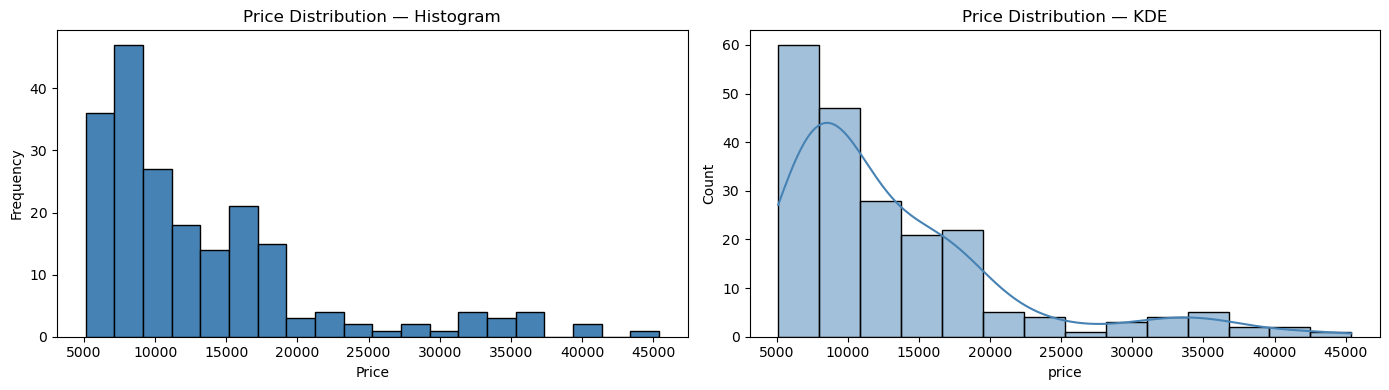

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['price'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title("Price Distribution — Histogram")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

# KDE
sns.histplot(df['price'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title("Price Distribution — KDE")

plt.tight_layout()
plt.show()

### 4.2 Horsepower Distribution

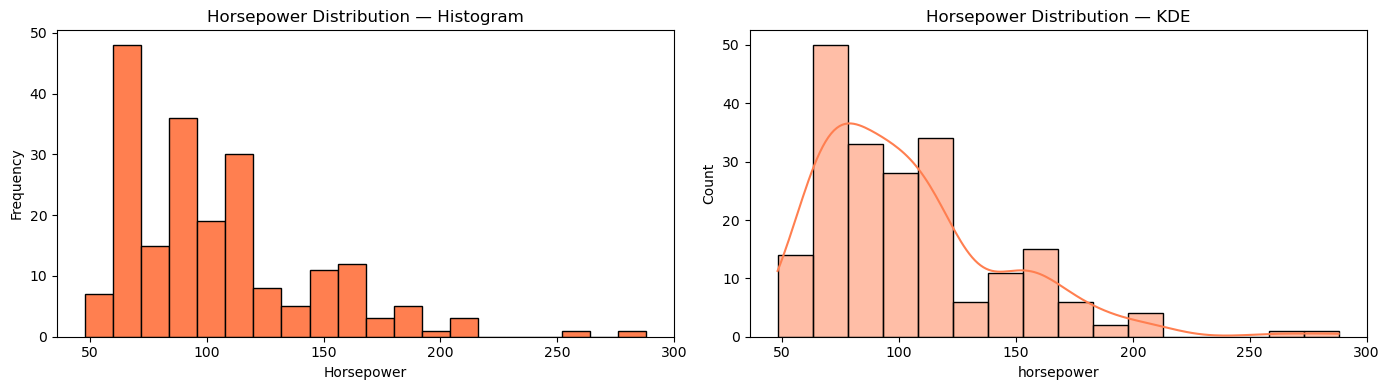

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['horsepower'], bins=20, color='coral', edgecolor='black')
axes[0].set_title("Horsepower Distribution — Histogram")
axes[0].set_xlabel("Horsepower")
axes[0].set_ylabel("Frequency")

sns.histplot(df['horsepower'], kde=True, ax=axes[1], color='coral')
axes[1].set_title("Horsepower Distribution — KDE")

plt.tight_layout()
plt.show()

### 4.3 Boxplots — Outlier Visualization

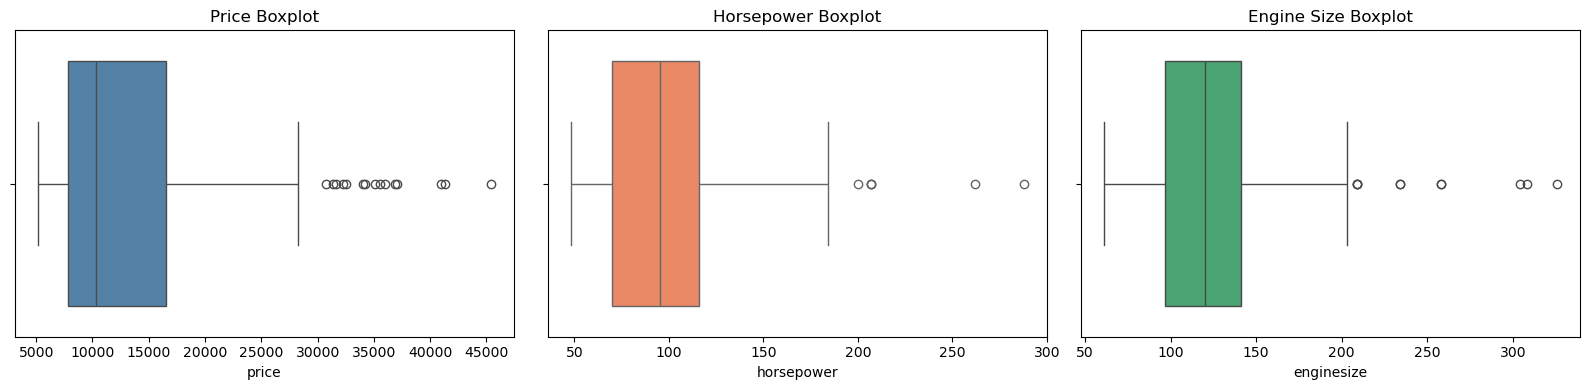

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(x=df['price'],       ax=axes[0], color='steelblue')
axes[0].set_title("Price Boxplot")

sns.boxplot(x=df['horsepower'],  ax=axes[1], color='coral')
axes[1].set_title("Horsepower Boxplot")

sns.boxplot(x=df['enginesize'],  ax=axes[2], color='mediumseagreen')
axes[2].set_title("Engine Size Boxplot")

plt.tight_layout()
plt.show()

### 4.4 Categorical Features

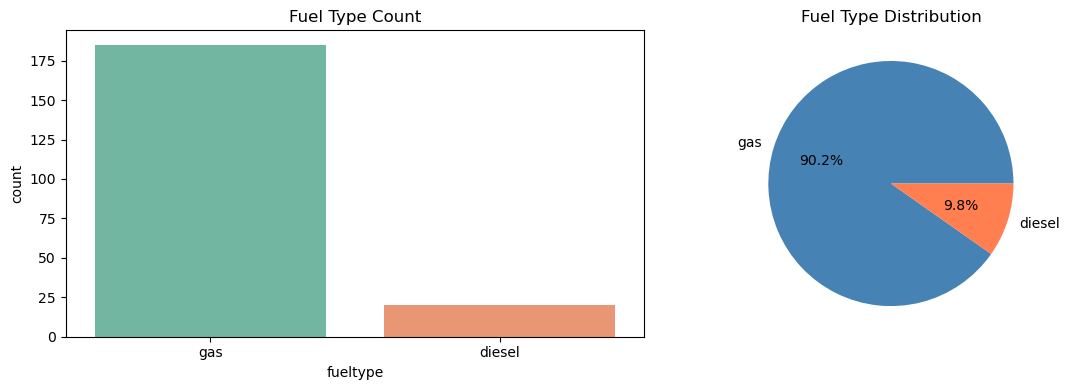

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
sns.countplot(x='fueltype', data=df, hue='fueltype', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Fuel Type Count")

# Pie chart
df['fueltype'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['steelblue', 'coral'], ax=axes[1]
)
axes[1].set_title("Fuel Type Distribution")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

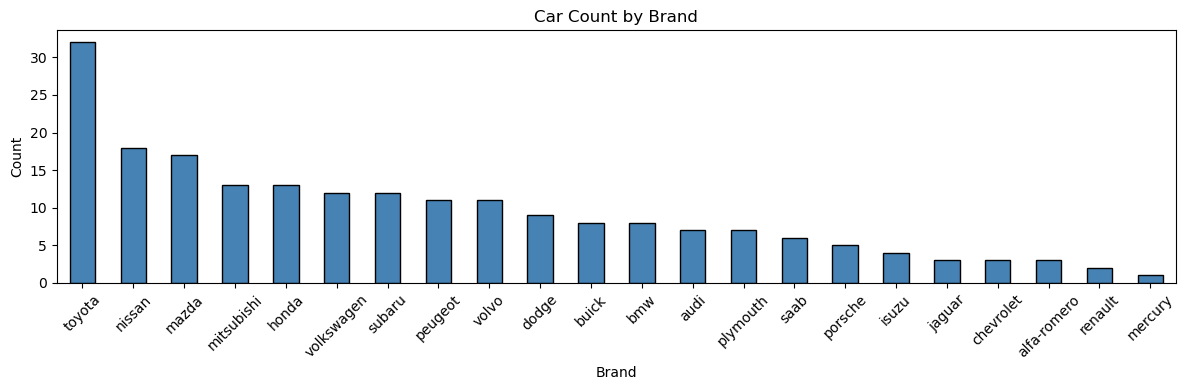

In [22]:
# Top brands by count
plt.figure(figsize=(12, 4))
df['brand'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Car Count by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📈 5. Bivariate Analysis (Two Variables)

### 5.1 Numerical vs Numerical — Scatter Plots with Regression Line

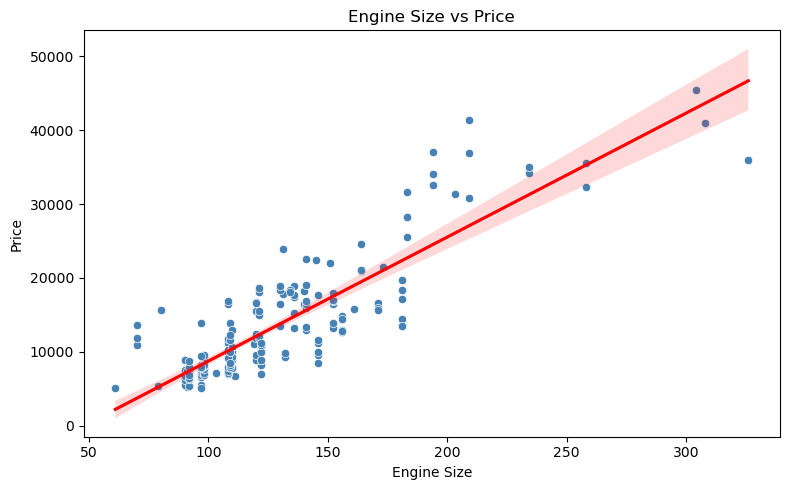

📌 Correlation (Engine Size vs Price): 0.87


In [23]:
# Engine Size vs Price (r = 0.87)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='enginesize', y='price', data=df, color='steelblue')
sns.regplot(x='enginesize', y='price', data=df, scatter=False, color='red')
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

corr = df['enginesize'].corr(df['price'])
print(f"📌 Correlation (Engine Size vs Price): {corr:.2f}")

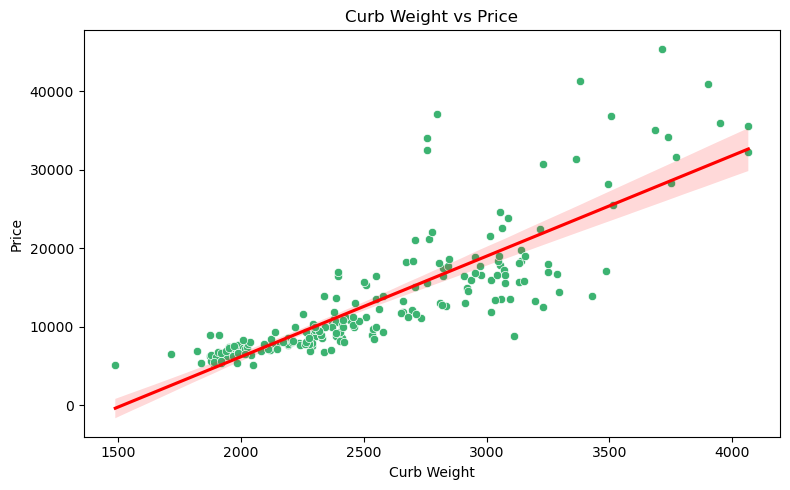

📌 Correlation (Curb Weight vs Price): 0.84


In [24]:
# Curb Weight vs Price (r = 0.84)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='curbweight', y='price', data=df, color='mediumseagreen')
sns.regplot(x='curbweight', y='price', data=df, scatter=False, color='red')
plt.title('Curb Weight vs Price')
plt.xlabel('Curb Weight')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

corr = df['curbweight'].corr(df['price'])
print(f"📌 Correlation (Curb Weight vs Price): {corr:.2f}")

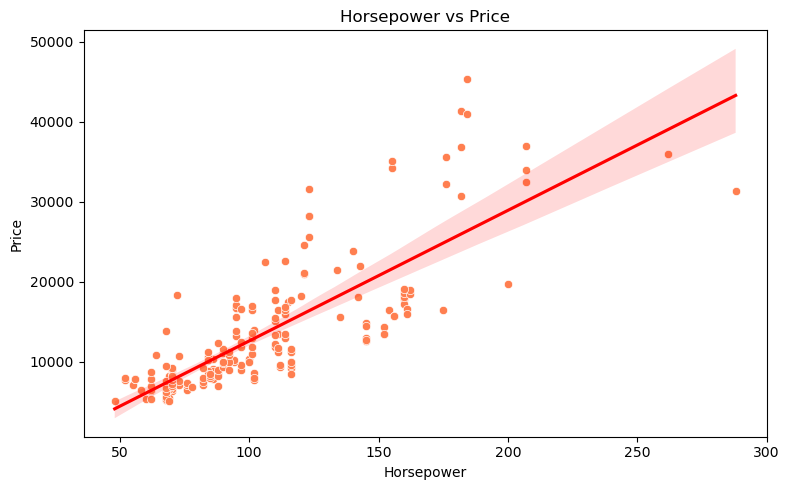

📌 Correlation (Horsepower vs Price): 0.81


In [25]:
# Horsepower vs Price (r = 0.81)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='horsepower', y='price', data=df, color='coral')
sns.regplot(x='horsepower', y='price', data=df, scatter=False, color='red')
plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

corr = df['horsepower'].corr(df['price'])
print(f"📌 Correlation (Horsepower vs Price): {corr:.2f}")

### 5.2 Categorical vs Numerical — Box Plots & Bar Plots

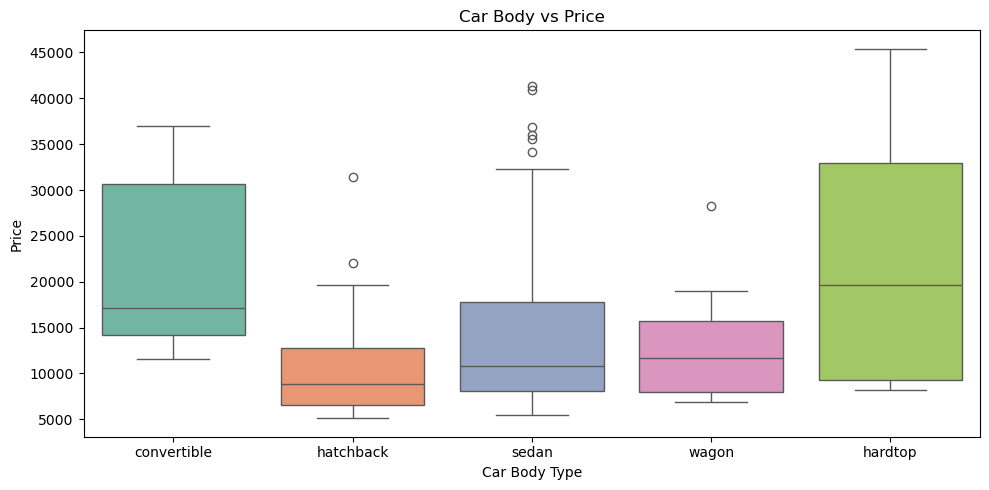

Mean Price by Car Body:
carbody
hardtop        22208.50
convertible    21890.50
sedan          14344.27
wagon          12371.96
hatchback      10376.65
Name: price, dtype: float64


In [27]:
# Car Body vs Price
plt.figure(figsize=(10, 5))
sns.boxplot(x='carbody', y='price', data=df, hue='carbody', palette='Set2', legend=False)
plt.title("Car Body vs Price")
plt.xlabel("Car Body Type")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

print("Mean Price by Car Body:")
print(df.groupby('carbody')['price'].mean().sort_values(ascending=False).round(2))

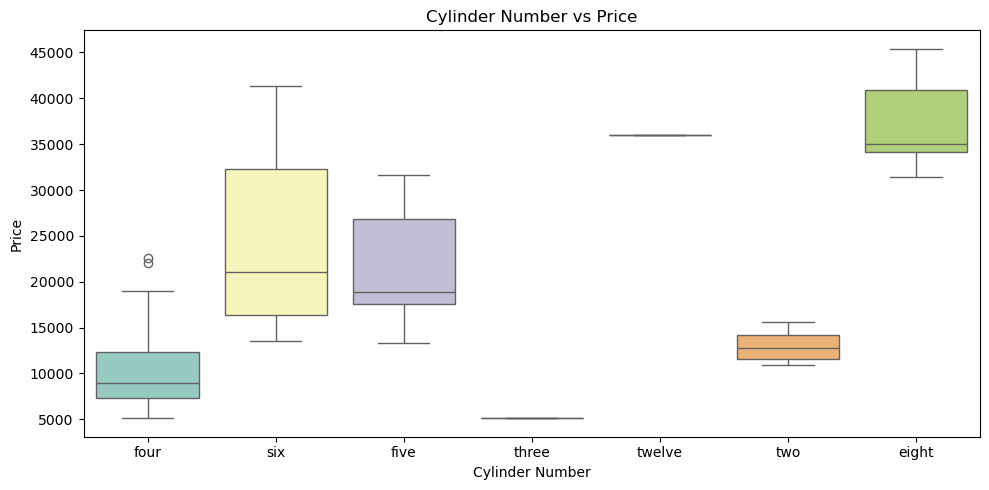

In [29]:
# Cylinder Number vs Price
plt.figure(figsize=(10, 5))
sns.boxplot(x='cylindernumber', y='price', data=df, hue='cylindernumber', palette='Set3', legend=False)
plt.title("Cylinder Number vs Price")
plt.xlabel("Cylinder Number")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

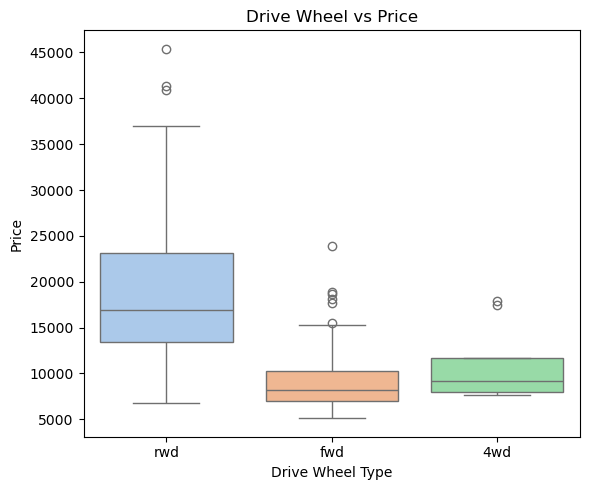

Mean Price by Drive Wheel:
drivewheel
rwd    19910.81
4wd    11087.46
fwd     9239.31
Name: price, dtype: float64


In [31]:
# Drive Wheel vs Price
plt.figure(figsize=(6, 5))
sns.boxplot(x='drivewheel', y='price', data=df, hue='drivewheel', palette='pastel', legend=False)
plt.title('Drive Wheel vs Price')
plt.xlabel('Drive Wheel Type')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

print("Mean Price by Drive Wheel:")
print(df.groupby('drivewheel')['price'].mean().sort_values(ascending=False).round(2))

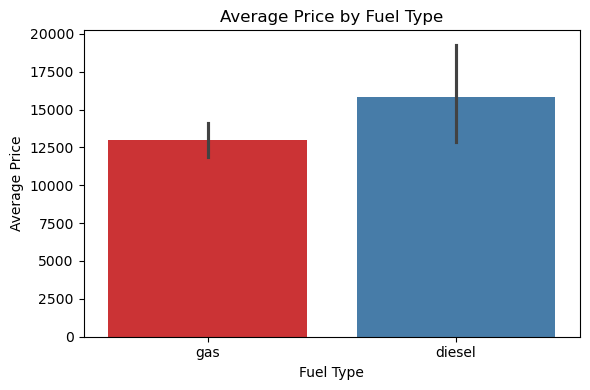

In [33]:
# Fuel Type vs Price
plt.figure(figsize=(6, 4))
sns.barplot(x='fueltype', y='price', data=df, hue='fueltype', palette='Set1', legend=False)
plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

### 5.3 Categorical vs Categorical

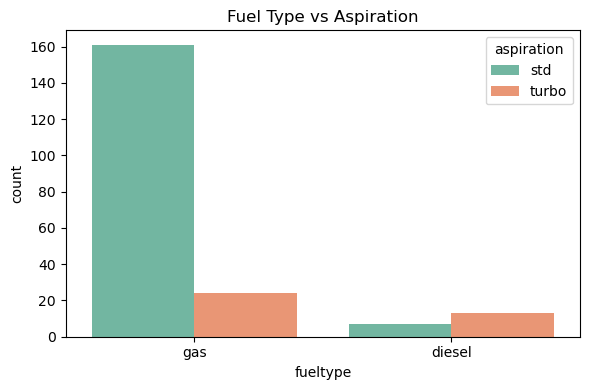

In [34]:
# Fuel Type vs Aspiration
plt.figure(figsize=(6, 4))
sns.countplot(x='fueltype', hue='aspiration', data=df, palette='Set2')
plt.title("Fuel Type vs Aspiration")
plt.tight_layout()
plt.show()

## 🔢 6. Pivot Table Analysis

Average Price by Fuel Type:
             price
fueltype          
diesel    15838.15
gas       12999.80


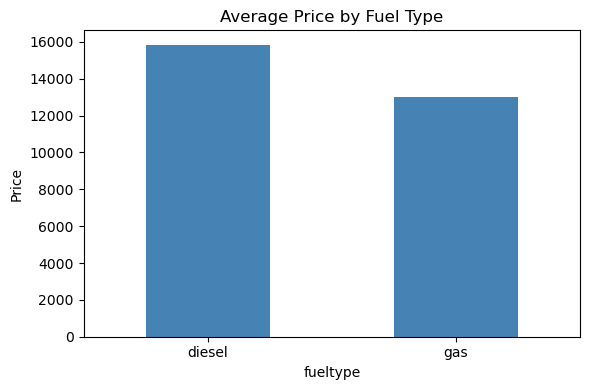

In [35]:
# Average Price by Fuel Type
pivot1 = pd.pivot_table(df, values='price', index='fueltype', aggfunc='mean').round(2)
print("Average Price by Fuel Type:")
print(pivot1)

pivot1.plot(kind='bar', figsize=(6, 4), color='steelblue', legend=False)
plt.title("Average Price by Fuel Type")
plt.ylabel("Price")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# Average Price by Car Body & Fuel Type
pivot2 = pd.pivot_table(df,
                        values='price',
                        index='carbody',
                        columns='fueltype',
                        aggfunc='mean').round(2)
print("Average Price by Car Body & Fuel Type:")
print(pivot2)

Average Price by Car Body & Fuel Type:
fueltype       diesel       gas
carbody                        
convertible       NaN  21890.50
hardtop      28176.00  21356.00
hatchback     7788.00  10414.17
sedan        14774.40  14264.62
wagon        19727.67  11368.91


In [37]:
# Average Engine Size by Drive Wheel
pivot3 = pd.pivot_table(df,
                        values='enginesize',
                        index='drivewheel',
                        aggfunc='mean').round(2)
print("Average Engine Size by Drive Wheel:")
print(pivot3)

Average Engine Size by Drive Wheel:
            enginesize
drivewheel            
4wd             110.11
fwd             108.78
rwd             157.51


## 🌡️ 7. Correlation Heatmap

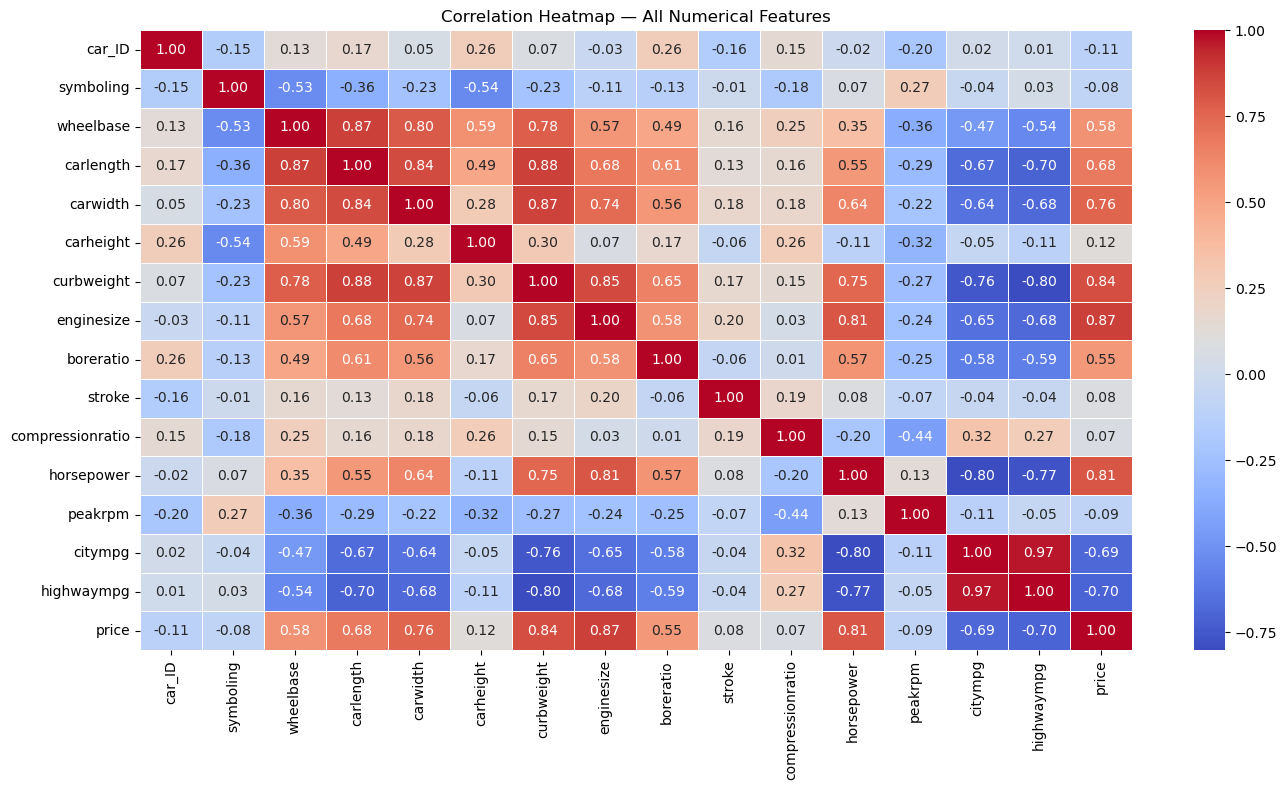

In [38]:
# Full correlation matrix
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap — All Numerical Features")
plt.tight_layout()
plt.show()

In [39]:
# Top correlations with Price
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("Features sorted by correlation with Price:")
print(price_corr.round(2))

Features sorted by correlation with Price:
enginesize          0.87
curbweight          0.84
horsepower          0.81
carwidth            0.76
carlength           0.68
wheelbase           0.58
boreratio           0.55
carheight           0.12
stroke              0.08
compressionratio    0.07
symboling          -0.08
peakrpm            -0.09
car_ID             -0.11
citympg            -0.69
highwaympg         -0.70
Name: price, dtype: float64


## ✅ 8. Key Findings & Conclusion

### Top Price Predictors:

| Feature | Correlation | Interpretation |
|---------|-------------|----------------|
| Engine Size | r = 0.87 | Strongest predictor |
| Curb Weight | r = 0.84 | Heavier cars cost more |
| Horsepower | r = 0.81 | More power = higher price |
| Car Width | r = 0.76 | Wider cars are pricier |
| Car Length | r = 0.68 | Longer cars cost more |
| City MPG | r = -0.69 | Better fuel economy = lower price |
| Highway MPG | r = -0.70 | Better fuel economy = lower price |

### Key Observations:
- **Engine size** is the strongest predictor of car price (r = 0.87)
- **15 luxury cars** (BMW, Jaguar, Porsche, Buick) above $30K were retained as valid data
- **Fuel efficiency** has a strong negative correlation with price
- **Rear-wheel drive (rwd)** cars have the highest average price
- **Hardtops and convertibles** command higher prices than sedans
- **Diesel cars** have higher average prices than petrol cars
- **5 brand typos** were corrected: `toyouta`, `vokswagen`, `vw`, `maxda`, `porcshce`